In [1]:
import anndata as ad
import pooch
import scanpy as sc

In [2]:
sc.set_figure_params(dpi=50, facecolor="white")

In [ ]:
def download_sample(sample_id: str, known_hash: str) -> ad.AnnData:
    path = pooch.retrieve(
        path=pooch.os_cache("scverse_tutorials"),
        url=f"https://exampledata.scverse.org/tutorials/neurips-2021/{sample_id}_filtered_feature_bc_matrix.h5",
        known_hash=known_hash,
    )
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    return sample_adata


samples = {
    "s1d1": "md5:a99285913ea3f3d22600d3d2f8a88e34",
    "s1d3": "md5:825f7f7578e3dc0b8955f5a97a402338",
}
adatas = {id_: download_sample(id_, known_hash) for id_, known_hash in samples.items()}
adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()

## Quality Control

In [4]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  # "MT-" for human, "Mt-" for mouse
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

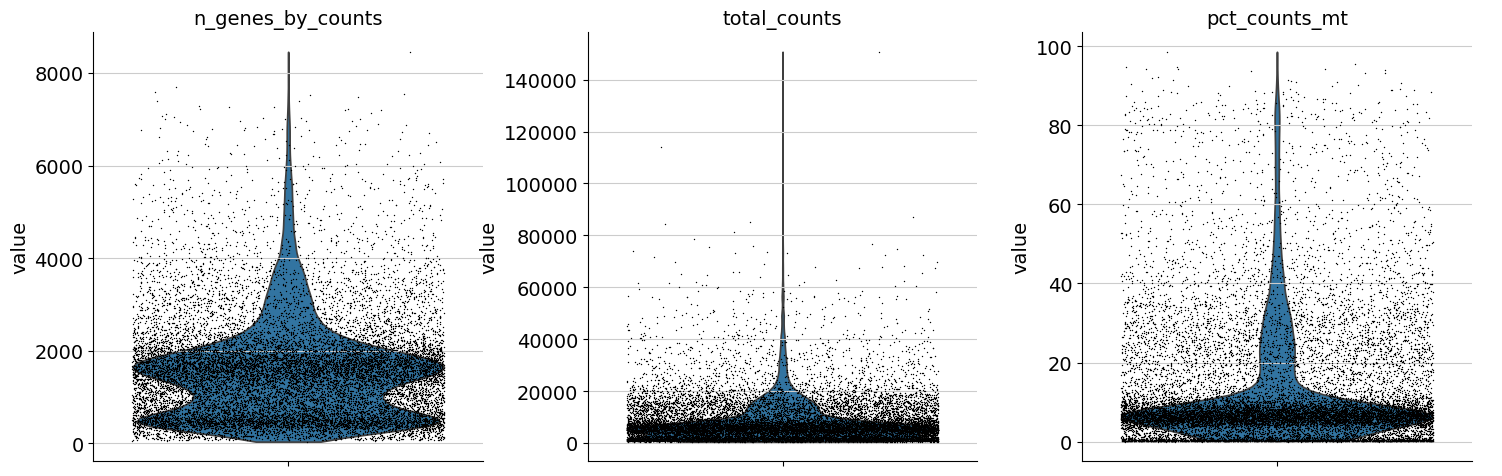

In [6]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

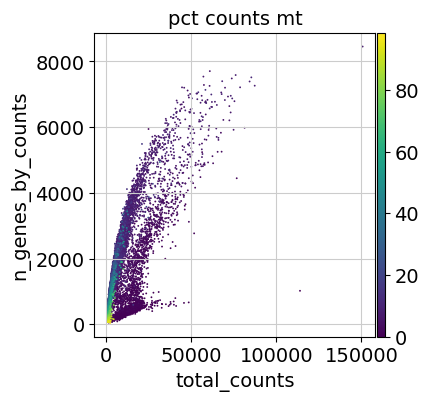

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [ ]:
pip install scrublet

In [11]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [12]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data:
sc.pp.log1p(adata)

In [13]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

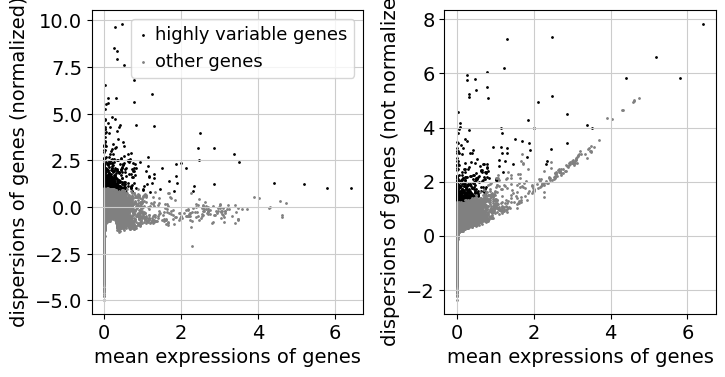

In [14]:
sc.pl.highly_variable_genes(adata)

In [15]:
sc.tl.pca(adata)

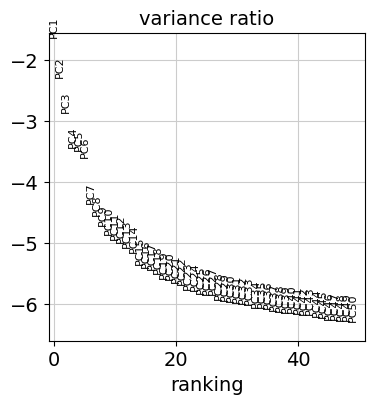

In [16]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [17]:
sc.pp.neighbors(adata)

2026-04-05 03:48:26.799574: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 03:48:26.938322: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 03:48:28.034475: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [18]:
sc.tl.umap(adata)

In [ ]:
sc.pl.umap(adata, color="sample")

In [ ]:
pip install leidenalg

In [ ]:
pip install --upgrade scanpy igraph leidenalg

In [23]:
#sc.tl.leiden(adata, flavor="igraph")
sc.tl.leiden(adata)

In [ ]:
sc.pl.umap(adata, color=["leiden"])

In [ ]:
adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype("category")
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
)

In [27]:
adata = adata[~adata.obs["predicted_doublet"].to_numpy()].copy()

In [ ]:
sc.pl.umap(
    adata, color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"], wspace=0.5, ncols=2
)

In [ ]:
!pip install celltypist
!pip install decoupler

In [33]:
import celltypist as ct
import decoupler as dc

In [35]:
sc.tl.leiden(adata, key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res2", resolution=2)

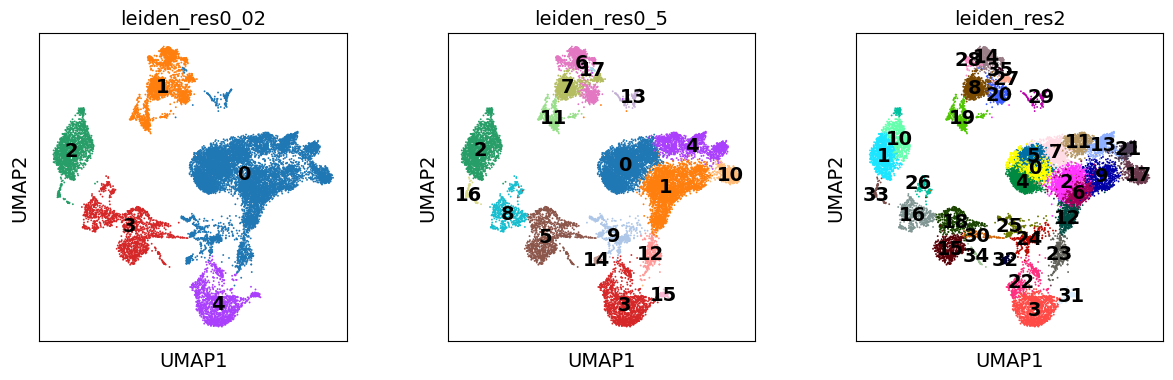

In [36]:
sc.pl.umap(
    adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
    legend_loc="on data",
)

In [37]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": ["MS4A1", "ITGB1", "COL4A4", "PRDM1", "IRF4", "PAX5", "BCL11A", "BLK", "IGHD", "IGHM"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

In [38]:
def group_max(adata: sc.AnnData, groupby: str) -> str:
    import pandas as pd

    agg = sc.get.aggregate(adata, by=groupby, func="mean")
    return pd.Series(agg.layers["mean"].sum(1), agg.obs[groupby]).idxmax()

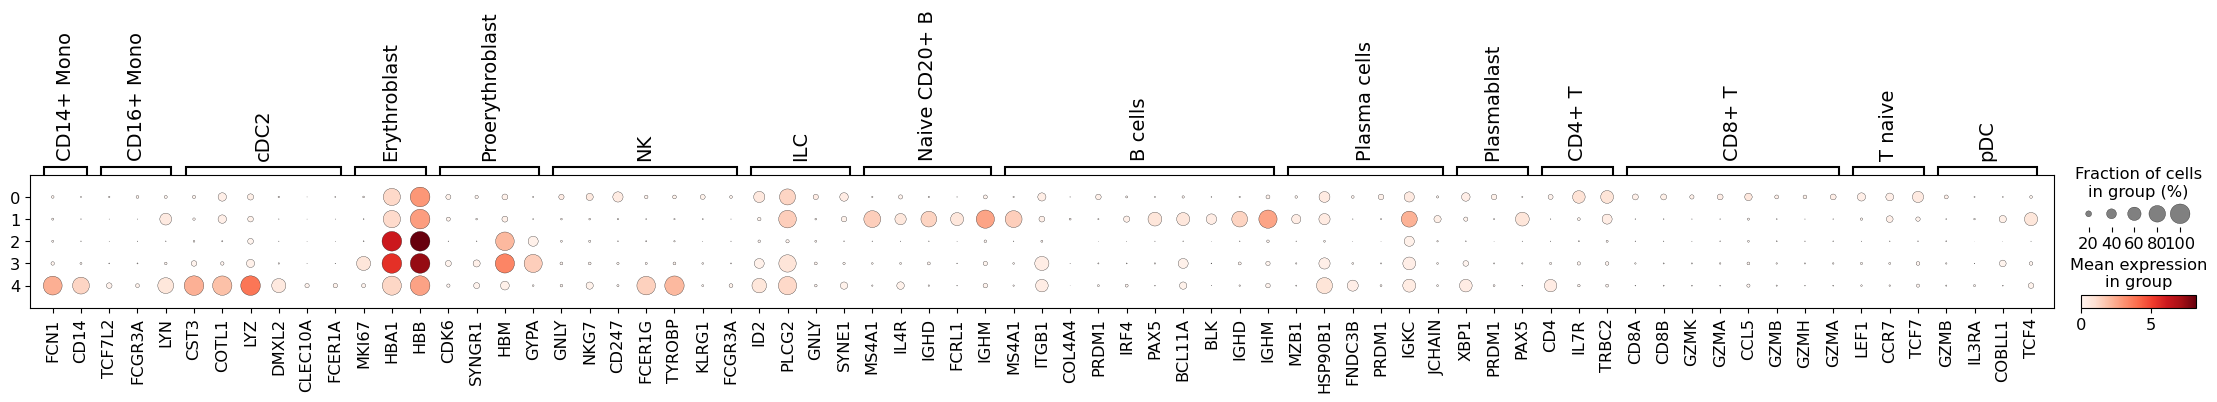

In [39]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_02")

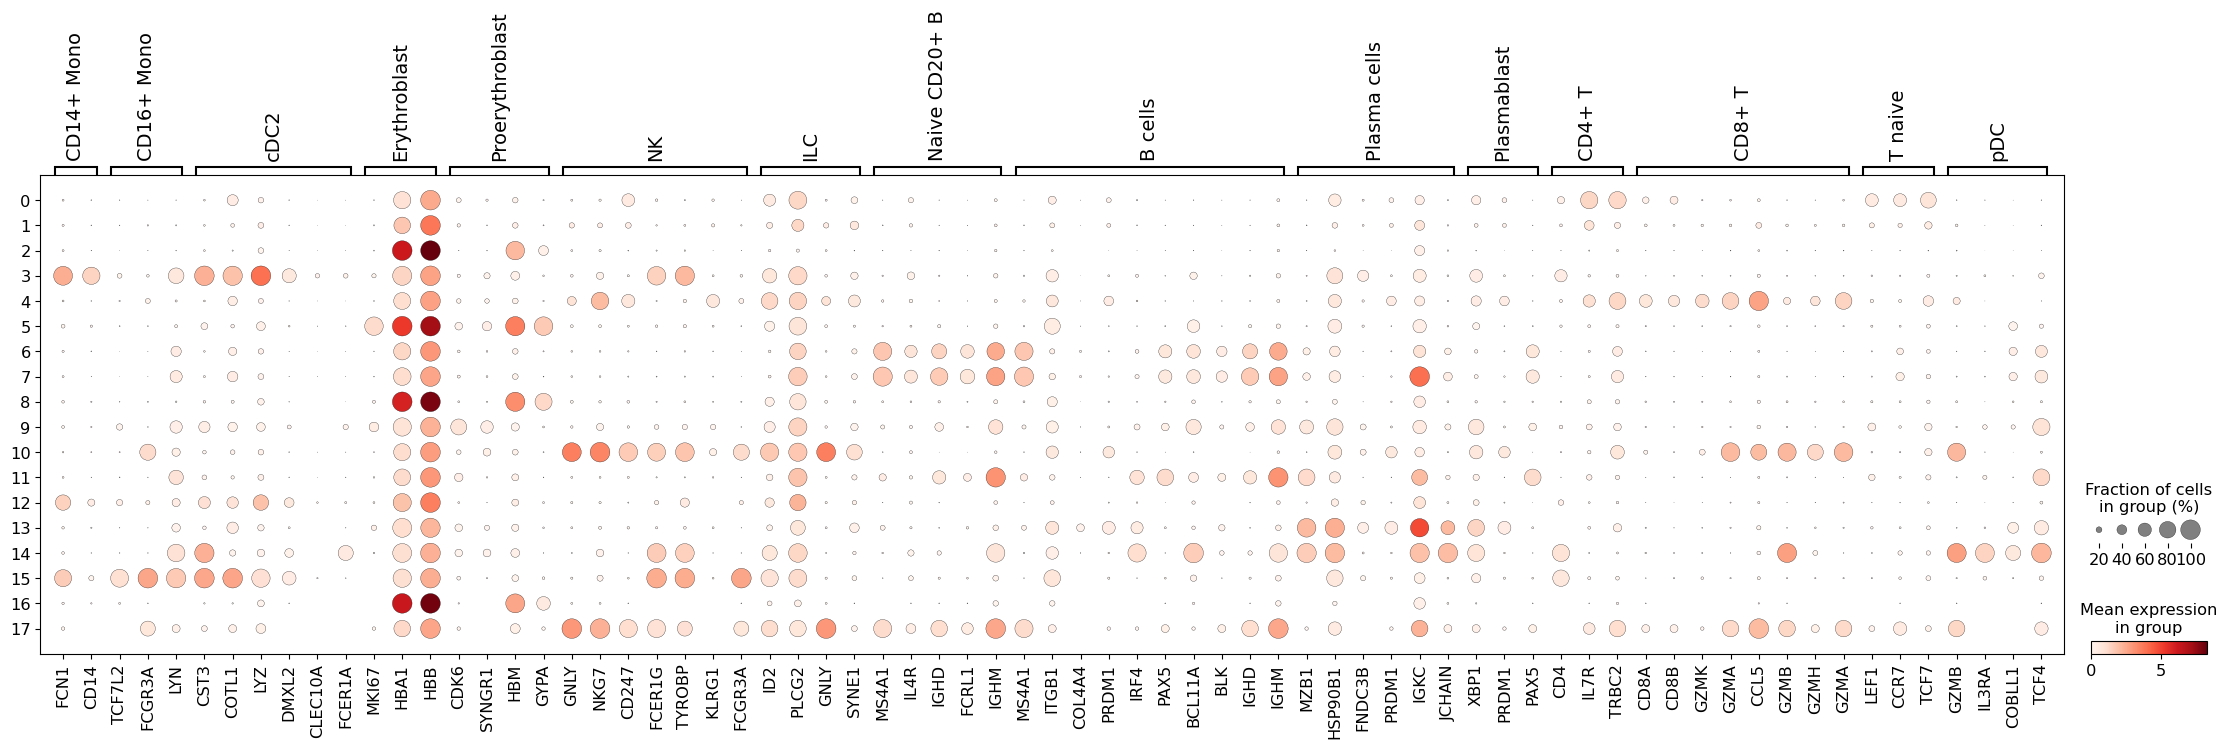

In [40]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_5")

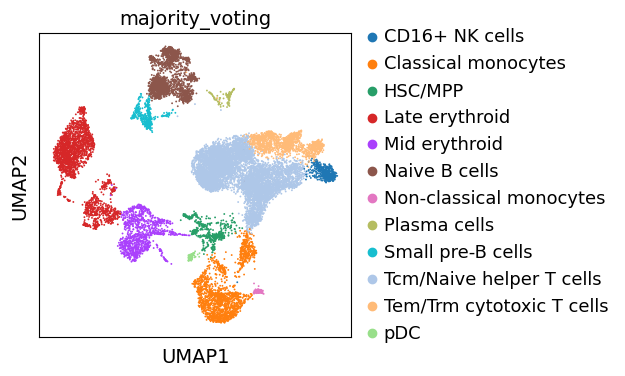

In [43]:
sc.pl.umap(adata, color="majority_voting", ncols=1)

In [50]:
import decoupler as dc

# 1. Fetch
markers = dc.get_resource("PanglaoDB")

# 2. Debug: Look for the column that specifies Human vs Mouse
# Common columns are 'taxon', 'ncbitaxonid', 'species', or 'organism'
possible_org_cols = ['taxon', 'ncbitaxonid', 'species', 'organism']
org_col = next((c for c in possible_org_cols if c in markers.columns), None)

if org_col:
    # Filter for Human (Taxon 9606 or name 'human')
    is_human = markers[org_col].astype(str).str.lower().isin(['human', '9606', 'hsapiens'])
    
    # Check for canonical markers - if column missing, skip this filter
    if "canonical_marker" in markers.columns:
        markers = markers[is_human & (markers["canonical_marker"])]
    else:
        markers = markers[is_human]
else:
    print("Could not find an organism column. Columns present are:", markers.columns.tolist())

# 3. Deduplicate (PanglaoDB uses 'genesymbol' or 'target' for the gene name)
gene_col = 'genesymbol' if 'genesymbol' in markers.columns else 'target'
markers = markers[~markers.duplicated(["cell_type", gene_col])]

markers.head()

Could not find an organism column. Columns present are: ['genesymbol', 'canonical_marker', 'cell_type', 'germ_layer', 'human', 'human_sensitivity', 'human_specificity', 'mouse', 'mouse_sensitivity', 'mouse_specificity', 'ncbi_tax_id', 'organ', 'ubiquitiousness']


,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
0,CTRB1,False,Enterocytes,Endoderm,True,0.000000,0.004394,True,0.003311,0.020480,9606,GI tract,0.017
1,CTRB1,True,Acinar cells,Endoderm,True,1.000000,0.000629,True,0.957143,0.015920,9606,Pancreas,0.017
2,KLK1,False,Distal tubule cells,Mesoderm,True,0.000000,0.008145,True,0.851064,0.011649,9606,Kidney,0.013
3,KLK1,True,Endothelial cells,Mesoderm,True,0.000000,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
4,KLK1,True,Acinar cells,Endoderm,True,0.833333,0.005031,True,0.314286,0.012826,9606,Pancreas,0.013


In [54]:
import decoupler as dc

# Set weight=None to bypass the weight requirement
dc.run_mlm(
    adata, 
    net=markers.rename(columns=dict(cell_type="source", genesymbol="target")), 
    weight=None,
    use_raw=False,
    verbose=True
)

Running mlm on mat with 16801 samples and 23427 targets for 158 sources.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:43<00:00, 21.56s/it]


mlm - fitting 118 multivariate models of 23427 observations with 23308 degrees of freedom



100%|██████████| 1/1 [00:29<00:00, 29.20s/it]


100%|██████████| 1/1 [00:29<00:00, 29.20s/it]


mlm - done


In [58]:
#adata.obsm["score_mlm"].head()

# View the first few rows of the MLM activity scores
#print(adata.obsm["mlm_estimate"].head())

adata.obsm["score_mlm"] = adata.obsm["mlm_estimate"]
adata.obsm["score_mlm"].head()

,Distal tubule cells,Endothelial cells,Acinar cells,Goblet cells,Plasmacytoid dendritic cells,Principal cells,Epithelial cells,Enterocytes,Paneth cells,Fibroblasts,...,Taste receptor cells,Neuroendocrine cells,Parathyroid chief cells,Retinal ganglion cells,Enterochromaffin cells,Urothelial cells,GABAergic neurons,Follicular cells,Ionocytes,Decidual cells
AAACCCAAGGATGGCT-1,-0.232594,-0.661465,-0.806855,0.162241,-0.454273,-0.855668,-1.299583,-1.077845,-1.387363,0.480319,...,-0.698815,-0.290649,-0.117029,-0.771583,-0.532057,-0.718752,0.276168,-0.840220,-0.288837,0.231395
AAACCCAAGGCCTAGA-1,-0.507196,-0.149373,0.598786,-0.145790,0.366481,0.066776,-2.015072,-1.979792,0.823622,1.759147,...,-0.751582,-0.156802,0.055235,-1.069197,-0.633231,-0.987212,0.445668,-0.470078,0.054830,0.319464
AAACCCAAGTGAGTGC-1,1.036757,-0.439930,0.545895,0.926935,-1.427479,0.025269,-1.531388,-0.980072,0.561133,0.371574,...,-0.556293,-0.561129,-0.097372,-0.234006,-0.029188,-0.416503,-0.142774,-0.597961,2.232781,-0.995162
AAACCCACAAGAGGCT-1,-0.754734,-0.244545,-1.518447,0.938046,12.091487,-1.704441,-1.857917,-1.294521,-1.092417,1.944786,...,-0.431291,-0.578934,-0.353177,-1.427035,-0.993335,-0.951291,1.236677,-0.943191,1.023588,2.045516
AAACCCACATCGTGGC-1,-0.344888,0.843339,1.308399,-0.155836,-1.308663,0.667160,-0.502956,0.050584,-0.667083,2.529423,...,1.794862,0.920297,0.116007,1.397454,-0.822584,-0.302886,-0.021652,-0.557977,0.054802,-1.332843


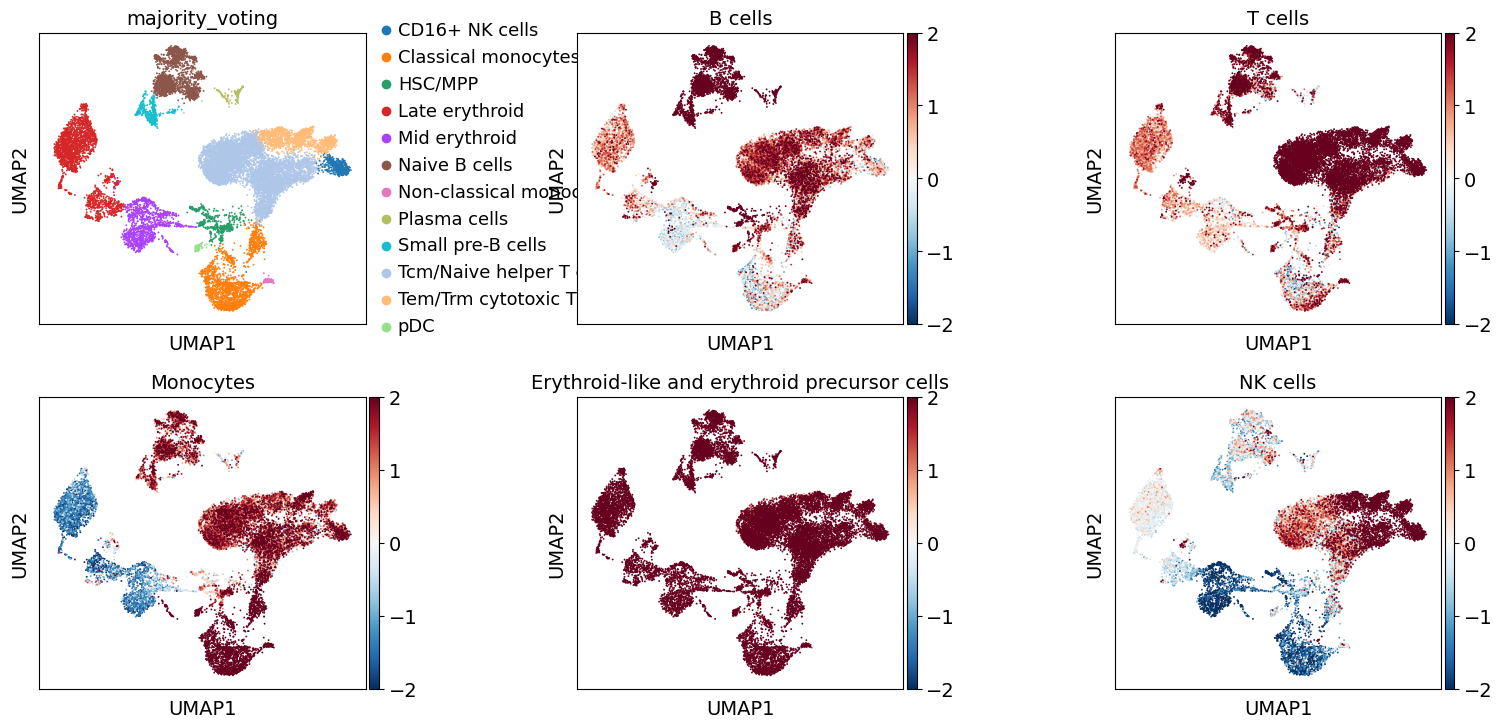

In [60]:
import decoupler as dc
import scanpy as sc

# 1. Get the activity object using the correct function and key
# Note: Ensure "mlm_estimate" is the key in your adata.obsm
acts = dc.get_acts(adata, obsm_key="mlm_estimate")

# 2. Transfer metadata from original adata to the acts object 
# so you can plot "majority_voting" alongside the scores
acts.obs['majority_voting'] = adata.obs['majority_voting']

# 3. Plot the UMAP
sc.pl.umap(
    acts,
    color=[
        "majority_voting",
        "B cells",
        "T cells",
        "Monocytes",
        "Erythroid-like and erythroid precursor cells",
        "NK cells",
    ],
    wspace=0.5,
    ncols=3,
    cmap='RdBu_r', # Red-Blue is standard for showing enrichment/depletion
    vmin=-2,
    vmax=2
)

In [64]:
import pandas as pd

# 1. Create a temporary DataFrame of the activity scores
# acts.X contains the MLM scores, acts.var_names are the cell types
df_acts = pd.DataFrame(acts.X, index=acts.obs_names, columns=acts.var_names)

# 2. Add the cluster labels to this DataFrame
df_acts['cluster'] = adata.obs['leiden_res0_5']

# 3. Calculate the mean score for every cell type in every cluster
df_means = df_acts.groupby('cluster').mean()

# 4. For each cluster, find the cell type with the highest average score
annotation_dict = df_means.idxmax(axis=1).to_dict()

# 5. Map the labels back to your original data
adata.obs["dc_anno"] = adata.obs["leiden_res0_5"].map(annotation_dict)

# Print the mapping to verify
print("Final Cluster Annotations:")
for cluster, cell_type in annotation_dict.items():
    print(f"Cluster {cluster}: {cell_type}")

Final Cluster Annotations:
Cluster 0: T memory cells
Cluster 1: Erythroid-like and erythroid precursor cells
Cluster 2: Erythroid-like and erythroid precursor cells
Cluster 3: Monocytes
Cluster 4: T cells
Cluster 5: Erythroid-like and erythroid precursor cells
Cluster 6: B cells naive
Cluster 7: B cells naive
Cluster 8: Erythroid-like and erythroid precursor cells
Cluster 9: Pancreatic progenitor cells
Cluster 10: NK cells
Cluster 11: B cells
Cluster 12: Monocytes
Cluster 13: Plasma cells
Cluster 14: Plasmacytoid dendritic cells
Cluster 15: Monocytes
Cluster 16: Erythroid-like and erythroid precursor cells
Cluster 17: B cells naive


... storing 'dc_anno' as categorical


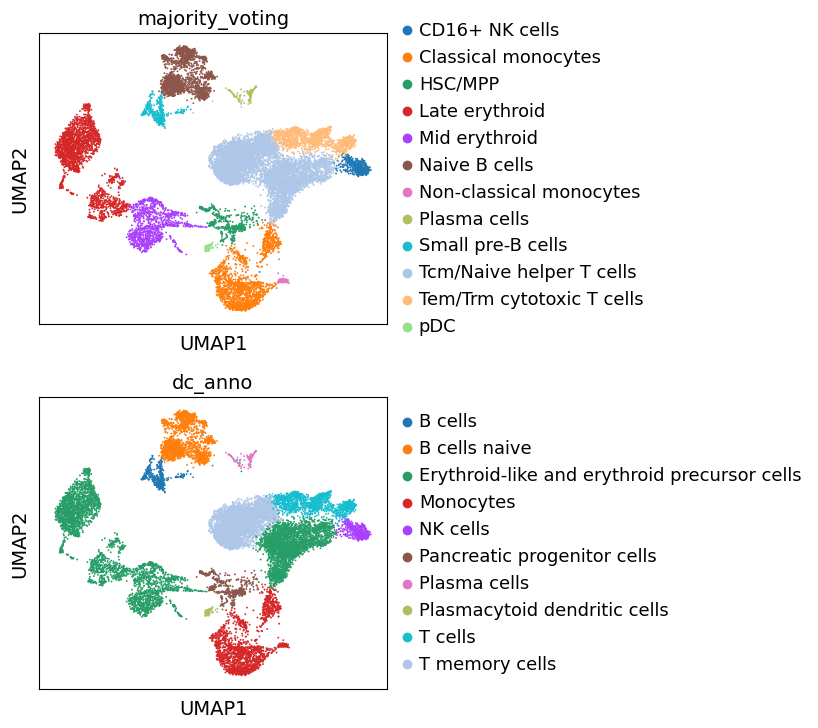

In [65]:
sc.pl.umap(adata, color=["majority_voting", "dc_anno"], ncols=1)

In [66]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res0_5")
# Filter those
sc.tl.filter_rank_genes_groups(adata, min_fold_change=1.5)

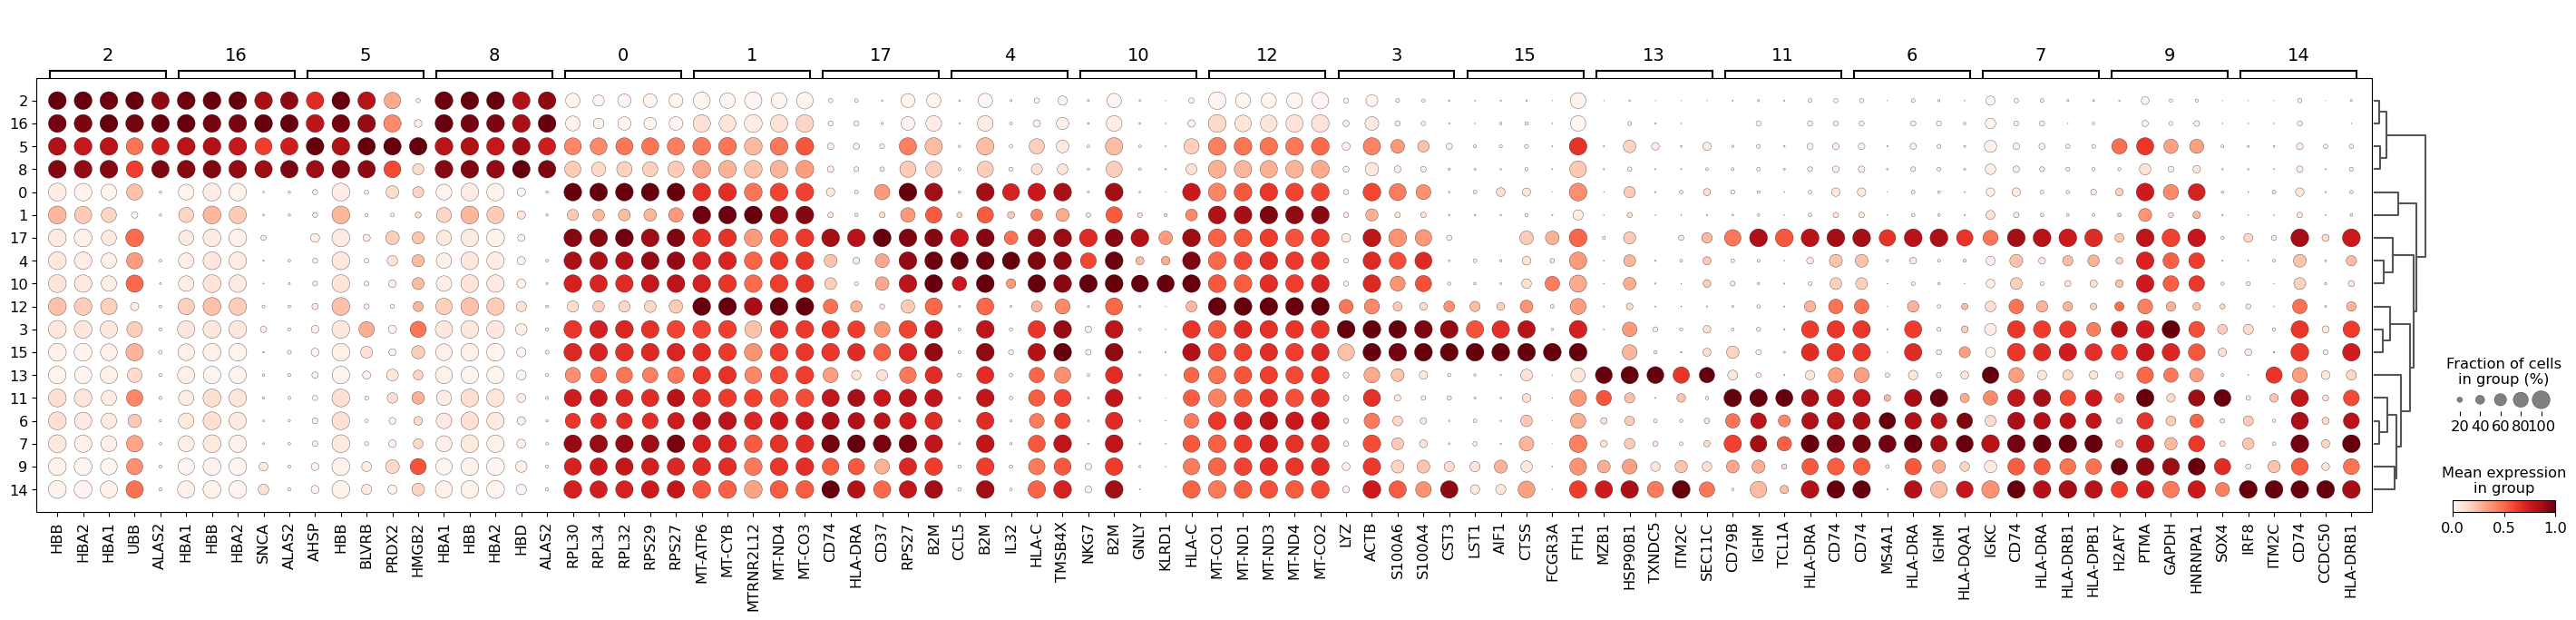

In [67]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res0_5", standard_scale="var", n_genes=5)

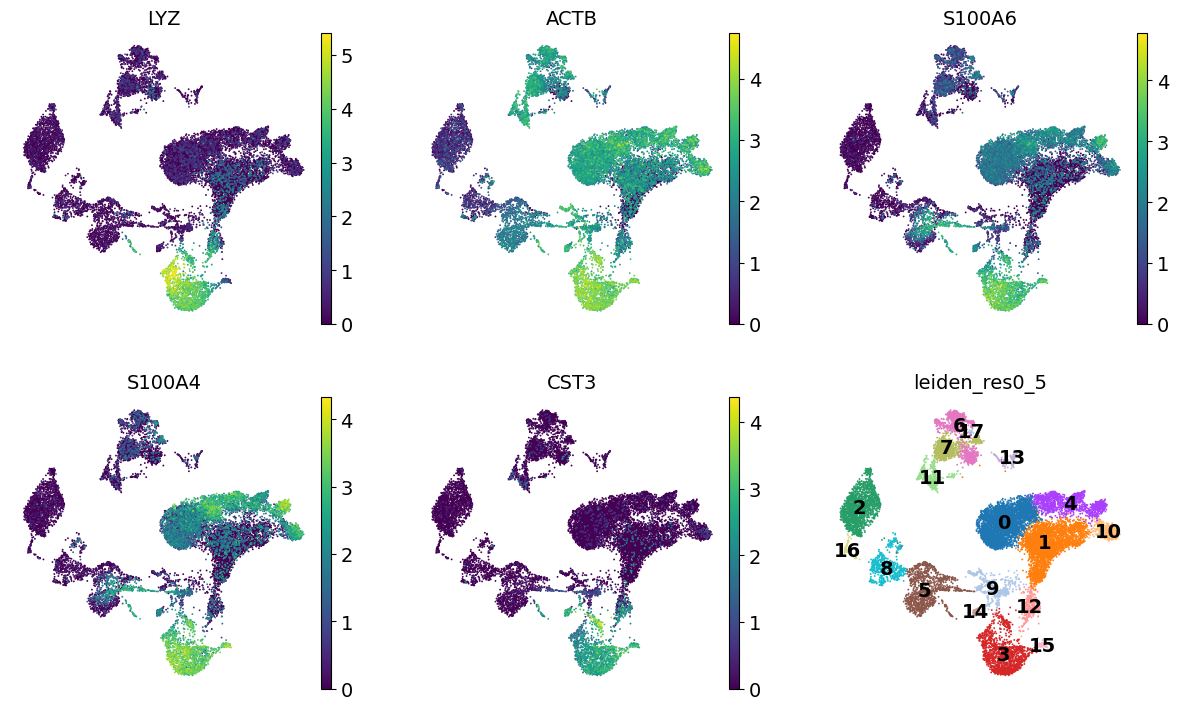

In [68]:
cluster3_genes = ["LYZ", "ACTB", "S100A6", "S100A4", "CST3"]
sc.pl.umap(adata, color=[*cluster3_genes, "leiden_res0_5"], legend_loc="on data", frameon=False, ncols=3)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

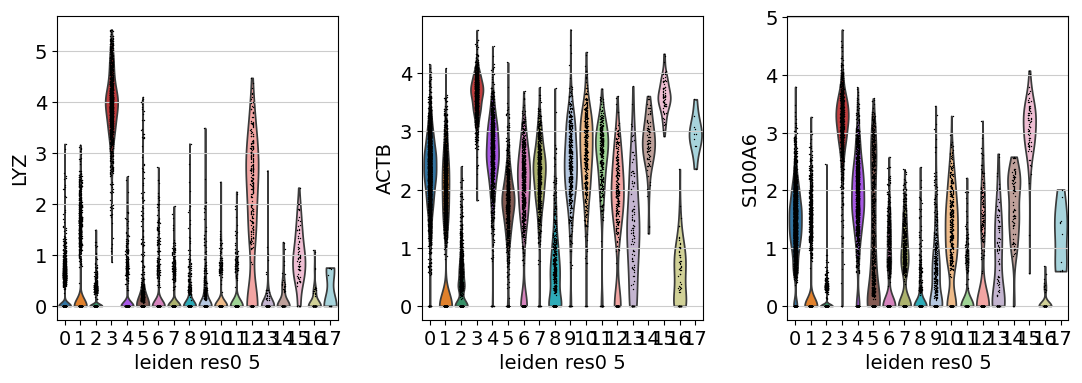

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


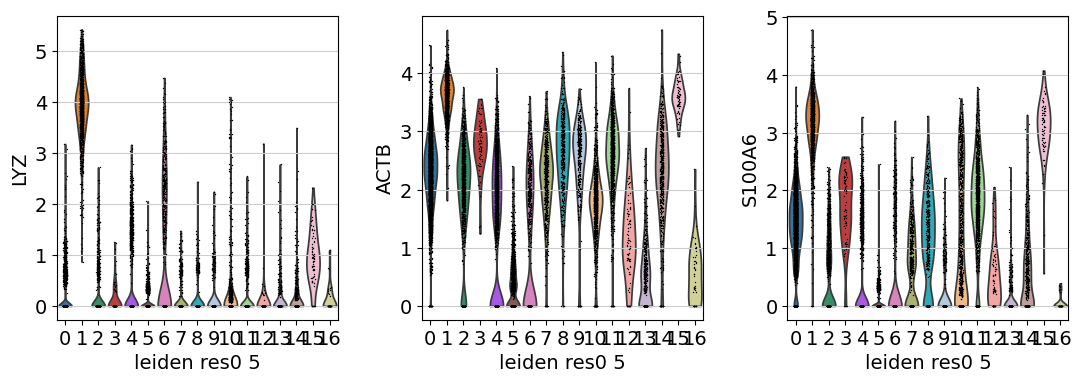

In [69]:
sc.pl.violin(adata, keys=cluster3_genes[0:3], groupby="leiden_res0_5", multi_panel=True)